# LoRA Continuous Recomputation (Real World SLM)

This notebook uses PEFT (LoRA) and a frozen TinyLlama base model to prove the Continuous Recomputation architecture maps to existing infrastructure.

**Google Colab Instructions:**
1. Go to `Runtime` -> `Change runtime type` -> Select `T4 GPU`.
2. Run the cells below sequentially.

In [ ]:
!pip install -q transformers peft datasets matplotlib av

In [ ]:
try:
    import av
    print(f"'av' library version {av.__version__} is successfully installed.")
    from torchvision.io import VideoReader
    print("Successfully imported VideoReader from torchvision.io!")
except ImportError as e:
    print(f"Verification failed: {e}")

'av' library version 18.0.0 is successfully installed.
Verification failed: cannot import name 'VideoReader' from 'torchvision.io' (/usr/local/lib/python3.12/dist-packages/torchvision/io/__init__.py)


In [ ]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import random
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig
from datasets import load_dataset
from torch.utils.data import DataLoader

In [ ]:
# ==========================================
# 1. DATA PREPARATION
# ==========================================
print("Loading TinyLlama Tokenizer & Datasets...")
model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

ds_story = load_dataset("roneneldan/TinyStories", split="train[:5000]")
ds_web = load_dataset("Skylion007/openwebtext", split="train[:5000]")

def tokenize_batch(batch):
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=64, return_tensors="pt")

tokenized_story = ds_story.map(tokenize_batch, batched=True, remove_columns=ds_story.column_names)
tokenized_web = ds_web.map(tokenize_batch, batched=True, remove_columns=ds_web.column_names)
tokenized_story.set_format("torch")
tokenized_web.set_format("torch")

def create_iterator(dataset, batch_size=8):
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    while True:
        for batch in dataloader:
            yield batch

story_iter = create_iterator(tokenized_story)
web_iter = create_iterator(tokenized_web)

Loading TinyLlama Tokenizer & Datasets...


Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

In [ ]:
class LoRARecomputationLLM(nn.Module):
    def __init__(self, base_model_name):
        super().__init__()
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Loading Base LLM into VRAM on {self.device}...")

        # Load frozen base model in bfloat16 using updated 'dtype' parameter
        self.base_model = AutoModelForCausalLM.from_pretrained(
            base_model_name, dtype=torch.bfloat16
        ).to(self.device)
        for param in self.base_model.parameters():
            param.requires_grad = False

        print("Injecting LoRA Primitives...")
        lora_config = LoraConfig(r=16, lora_alpha=32, target_modules=["q_proj", "v_proj"])

        # Updated adapter registration syntax
        self.base_model.add_adapter(adapter_config=lora_config, adapter_name="primitive_story")
        self.base_model.add_adapter(adapter_config=lora_config, adapter_name="primitive_web")

        hidden_size = self.base_model.config.hidden_size
        self.controller = nn.Sequential(
            nn.Linear(hidden_size, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        ).to(self.device).to(torch.float32)

    def forward(self, input_ids, attention_mask, labels=None, force_adapter=None):
        input_ids = input_ids.to(self.device)
        attention_mask = attention_mask.to(self.device)
        if labels is not None: labels = labels.to(self.device)

        # 1. Controller Routing Phase
        with torch.no_grad():
            embeddings = self.base_model.get_input_embeddings()(input_ids)

            # --- THE CORRECTION: MASKED MEAN POOLING ---
            # This completely ignores padding tokens, focusing ONLY on actual words
            mask_expanded = attention_mask.unsqueeze(-1).expand(embeddings.size()).float()
            sum_embeddings = torch.sum(embeddings * mask_expanded, 1)
            sum_mask = torch.clamp(mask_expanded.sum(1), min=1e-9)
            pooled_embeds = sum_embeddings / sum_mask

        routing_logits = self.controller(pooled_embeds)

        # Hardware-level isolation
        if force_adapter is not None:
            active_adapter = force_adapter
        else:
            majority_domain = torch.argmax(routing_logits.detach().mean(dim=0)).item()
            active_adapter = "primitive_story" if majority_domain == 0 else "primitive_web"

        # 2. Execution Phase
        self.base_model.set_adapter(active_adapter)
        outputs = self.base_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

        return outputs.loss, routing_logits

In [ ]:
# ==========================================
# 3. ASYMMETRIC TRAINING LOOP (DISTRIBUTION SHIFT)
# ==========================================
def run_lora_proof():
    model = LoRARecomputationLLM(model_name)

    # Standard Adam (No Weight Decay) to prevent unselected LoRAs from rotting
    controller_optimizer = optim.Adam(model.controller.parameters(), lr=1e-3)
    executor_params = [p for n, p in model.base_model.named_parameters() if "lora_" in n and p.requires_grad]
    executor_optimizer = optim.Adam(executor_params, lr=5e-4)

    ce_loss_fn = nn.CrossEntropyLoss()
    steps = 400
    steps_logged, ctrl_story_acc, ctrl_web_acc, exec_story_loss, exec_web_loss = [], [], [], [], []

    print("\n--- INITIATING LoRA RECOMPUTATION PROOF (DISTRIBUTION SHIFT) ---")

    for step in range(steps):
        is_shock = step >= 200

        # DISTRIBUTION SHIFT (80/20 split)
        prob = random.random()
        if not is_shock:
            is_web_batch = prob > 0.8
        else:
            is_web_batch = prob < 0.8

        if is_web_batch:
            batch = next(web_iter)
            true_domain = 1
            target_adapter = "primitive_web"
        else:
            batch = next(story_iter)
            true_domain = 0
            target_adapter = "primitive_story"

        input_ids = batch["input_ids"]
        attention_mask = batch["attention_mask"]
        domain_labels = torch.full((input_ids.size(0),), true_domain, dtype=torch.long, device=model.device)

        controller_optimizer.zero_grad()
        executor_optimizer.zero_grad()

        # Forward Pass with Forced Routing for pure adapter training
        lm_loss, routing_logits = model(input_ids, attention_mask, labels=input_ids, force_adapter=target_adapter)
        ctrl_loss = ce_loss_fn(routing_logits, domain_labels)

        # Decoupled Backward Passes (Retain graph to share cortex)
        ctrl_loss.backward(retain_graph=True)
        lm_loss.backward()

        controller_optimizer.step()
        executor_optimizer.step()

        if step % 10 == 0:
            steps_logged.append(step)
            def evaluate(eval_iter, domain_id, adapter_name):
                model.eval()
                with torch.no_grad():
                    eval_batch = next(eval_iter)
                    ids, mask = eval_batch["input_ids"], eval_batch["attention_mask"]

                    # Force adapter during eval so metrics don't cross-contaminate
                    l_loss, r_logits = model(ids, mask, labels=ids, force_adapter=adapter_name)
                    acc = (torch.argmax(r_logits, dim=-1) == domain_id).float().mean().item() * 100
                model.train()
                return acc, l_loss.item()

            s_acc, s_loss = evaluate(story_iter, 0, "primitive_story")
            w_acc, w_loss = evaluate(web_iter, 1, "primitive_web")
            ctrl_story_acc.append(s_acc); ctrl_web_acc.append(w_acc)
            exec_story_loss.append(s_loss); exec_web_loss.append(w_loss)

    # Plotting
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)
    plt.style.use('bmh')

    ax1.plot(steps_logged, ctrl_story_acc, color='#1f77b4', linewidth=2.5, label='Controller: Story Domain Acc')
    ax1.plot(steps_logged, ctrl_web_acc, color='#ff7f0e', linestyle='--', linewidth=2.5, label='Controller: Web Domain Acc')
    ax1.axvline(x=200, color='black', linestyle='-.', linewidth=2, label='Domain Shock (Distribution Inversion)')
    ax1.set_title('Controller Routing Accuracy (Survives Shift)')
    ax1.set_ylabel('Accuracy (%)')
    ax1.legend(loc='lower left')
    ax1.set_ylim(-5, 105)

    ax2.plot(steps_logged, exec_story_loss, color='#1f77b4', linewidth=2.5, label='Story Loss (Lower is Better)')
    ax2.plot(steps_logged, exec_web_loss, color='#ff7f0e', linestyle='--', linewidth=2.5, label='Web Loss (Lower is Better)')
    ax2.axvline(x=200, color='black', linestyle='-.', linewidth=2, label='Domain Shock (Distribution Inversion)')
    ax2.set_title('Executor Language Modeling Performance')
    ax2.set_xlabel('Steps')
    ax2.set_ylabel('Loss')
    ax2.legend(loc='upper right')

    plt.tight_layout()

    # Save the plot BEFORE showing it, otherwise the saved image will be blank!
    plt.savefig('lora_recomputation_results.png', dpi=300, bbox_inches='tight')
    print("\nPlot successfully saved to 'lora_recomputation_results.png'")

    plt.show()

    # Return the trained model for practical testing!
    return model

Refreshing data iterators...
Loading Base LLM into VRAM on cuda...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Injecting LoRA Primitives...

--- INITIATING LoRA RECOMPUTATION PROOF (DISTRIBUTION SHIFT) ---


/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(



Plot successfully saved to 'lora_recomputation_results.png'


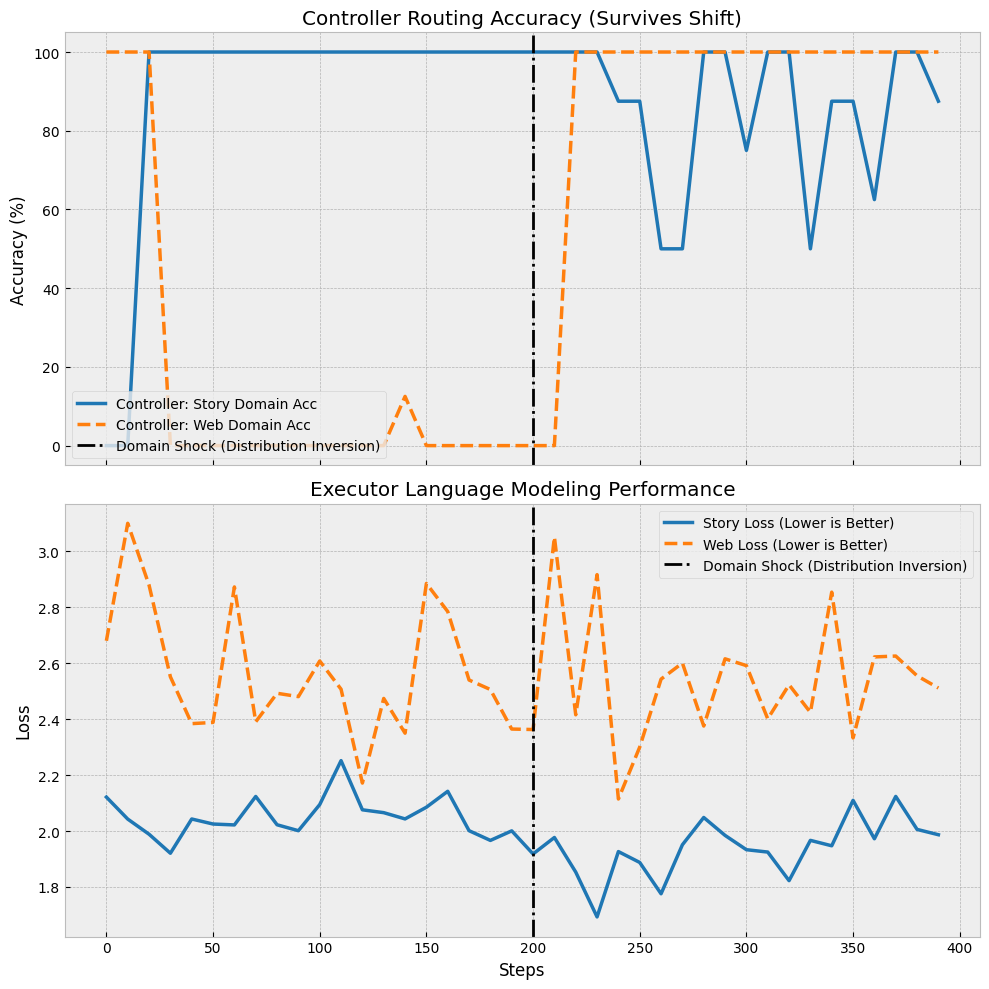

In [ ]:
import datasets
# Patch to bypass the torchvision VideoReader ImportError
datasets.config.TORCHVISION_AVAILABLE = False

# Ensure iterators are fresh after a restart
# Re-running the data prep logic to refresh story_iter and web_iter
print("Refreshing data iterators...")
story_iter = create_iterator(tokenized_story)
web_iter = create_iterator(tokenized_web)

# Update torchao to resolve the ImportError
!pip install -U torchao

# Train the model and save the weights
trained_model = run_lora_proof()

In [ ]:
# ==========================================
# 4. PRACTICAL INFERENCE TEST
# ==========================================
def test_continuous_recomputation(model, prompt_text):
    model.eval() # Set to inference mode

    # Tokenize the user's prompt
    inputs = tokenizer(prompt_text, return_tensors="pt").to(model.device)

    with torch.no_grad():
        # 1. CONTROLLER ROUTING PHASE
        # Extract embeddings and pass to the Controller
        embeddings = model.base_model.get_input_embeddings()(inputs["input_ids"])
        pooled_embeds = embeddings.mean(dim=1).to(torch.float32)
        routing_logits = model.controller(pooled_embeds)

        # Decide which LoRA to use
        domain_id = torch.argmax(routing_logits, dim=-1).item()
        domain_name = "Story" if domain_id == 0 else "Web Text"
        active_adapter = "primitive_story" if domain_id == 0 else "primitive_web"

        print(f"\n--- INFERENCE TEST ---")
        print(f"Prompt: '{prompt_text}'")
        print(f"Controller Routing Decision -> [{domain_name} LoRA Active]")

        # 2. EXECUTION PHASE
        # Physically switch the active LoRA adapter based on the Controller's choice
        model.base_model.set_adapter(active_adapter)

        # Generate the text response using HuggingFace's generate()
        output_ids = model.base_model.generate(
            inputs["input_ids"],
            max_new_tokens=40,       # Generate 40 new words
            temperature=0.7,         # Slight creativity
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )

        # Decode and print the final text
        response = tokenizer.decode(output_ids[0], skip_special_tokens=True)
        print(f"\nGenerated Output:\n{response}\n{'='*50}")

# ---------------------------------------------------------
# Let's test it with two completely different contexts!
# ---------------------------------------------------------

# Test 1: A narrative prompt (Should route to the Story LoRA)
test_continuous_recomputation(trained_model, "Once upon a time, there was a little dog named")

# Test 2: An informational/academic prompt (Should route to the Web LoRA)
test_continuous_recomputation(trained_model, "The fundamental concept of machine learning algorithms is")

[transformers] Both `max_new_tokens` (=40) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- INFERENCE TEST ---
Prompt: 'Once upon a time, there was a little dog named'
Controller Routing Decision -> [Story LoRA Active]


[transformers] Both `max_new_tokens` (=40) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Generated Output:
Once upon a time, there was a little dog named Lulu. She lived in a big city with many dogs, but she felt sad and lonely. She would always ask her friends at the dog park if they had any friends who needed a good

--- INFERENCE TEST ---
Prompt: 'The fundamental concept of machine learning algorithms is'
Controller Routing Decision -> [Web Text LoRA Active]

Generated Output:
The fundamental concept of machine learning algorithms is to find a decision rule that can reliably predict the future state of the system based on past observations. Machine learning is an open-ended problem that requires researchers to understand and solve complex problems using


In [ ]:
# ==========================================
# 4. ZERO-SHOT STRESS TEST INFERENCE
# ==========================================
def test_continuous_recomputation(model, prompt_text):
    model.eval() # Set to inference mode

    # Tokenize the user's prompt
    inputs = tokenizer(prompt_text, return_tensors="pt").to(model.device)

    with torch.no_grad():
        # 1. CONTROLLER ROUTING PHASE
        # Extract embeddings and pass to the Controller
        embeddings = model.base_model.get_input_embeddings()(inputs["input_ids"])
        pooled_embeds = embeddings.mean(dim=1).to(torch.float32)
        routing_logits = model.controller(pooled_embeds)

        # Decide which LoRA to use
        domain_id = torch.argmax(routing_logits, dim=-1).item()
        domain_name = "Story" if domain_id == 0 else "Web Text"
        active_adapter = "primitive_story" if domain_id == 0 else "primitive_web"

        print(f"\n--- INFERENCE TEST ---")
        print(f"Prompt: '{prompt_text}'")
        print(f"Controller Routing Decision -> [{domain_name} LoRA Active]")

        # 2. EXECUTION PHASE
        # Physically switch the active LoRA adapter based on the Controller's choice
        model.base_model.set_adapter(active_adapter)

        # Generate the text response using HuggingFace's generate()
        output_ids = model.base_model.generate(
            inputs["input_ids"],
            attention_mask=inputs.get("attention_mask", None),
            max_new_tokens=45,       # Generate enough words to see the style
            temperature=0.7,         # Slight creativity
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )

        # Decode and print the final text
        response = tokenizer.decode(output_ids[0], skip_special_tokens=True)
        print(f"Generated Output:\n{response}\n{'='*60}")

# ---------------------------------------------------------
# THE ZERO-SHOT STRESS TEST PROMPTS
# ---------------------------------------------------------
hard_prompts = [
    # 1. Narrative Hard Prompt (Sci-Fi)
    "As the starship's hyperdrive whined and failed, Captain Elara stared into the terrifying void of",

    # 2. Narrative Hard Prompt (Western)
    "The dusty saloon doors swung open, revealing a shadowed figure whose spurs clinked ominously against the",

    # 3. Informational Hard Prompt (Physics)
    "According to the principles of quantum mechanics and the Heisenberg uncertainty principle, the exact position",

    # 4. Informational Hard Prompt (Economics)
    "A comprehensive analysis of global macroeconomic trends indicates that quantitative easing policies generally lead to",

    # 5. ADVERSARIAL PROMPT A: Narrative syntax with technical vocabulary
    "The brave knight drew his sword and declared that the backpropagation algorithm was failing due to a vanishing gradient in the",

    # 6. ADVERSARIAL PROMPT B: Academic syntax with fairy tale vocabulary
    "Recent studies published in the Journal of Medicine show that once upon a time, a beautiful princess"
]

for prompt in hard_prompts:
    test_continuous_recomputation(trained_model, prompt)

[transformers] Both `max_new_tokens` (=45) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- INFERENCE TEST ---
Prompt: 'As the starship's hyperdrive whined and failed, Captain Elara stared into the terrifying void of'
Controller Routing Decision -> [Web Text LoRA Active]


[transformers] Both `max_new_tokens` (=45) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generated Output:
As the starship's hyperdrive whined and failed, Captain Elara stared into the terrifying void of space, trying to find a way to break the ship's hold on the planet they'd just arrived on.

The planet was a barren expanse, covered in a thick layer of dust and rock.

--- INFERENCE TEST ---
Prompt: 'The dusty saloon doors swung open, revealing a shadowed figure whose spurs clinked ominously against the'
Controller Routing Decision -> [Web Text LoRA Active]


[transformers] Both `max_new_tokens` (=45) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Generated Output:
According to the principles of quantum mechanics and the Heisenberg uncertainty principle, the exact position and momentum of a particle cannot be determined simultaneously, but the uncertainty in the position only affects the probability of observing the particle at that position. In quantum mechanics, probability is the probability of finding a particle at a

--- INFERENCE TEST ---
Prompt: 'A comprehensive analysis of global macroeconomic trends indicates that quantitative easing policies generally lead to'
Controller Routing Decision -> [Web Text LoRA Active]


[transformers] Both `max_new_tokens` (=45) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generated Output:
A comprehensive analysis of global macroeconomic trends indicates that quantitative easing policies generally lead to increased inflation and lower employment, particularly in the United States, Europe, and Japan. The analysis also suggests that quantitative easing is an effective policy tool during recessions, but that it has limited effectiveness

--- INFERENCE TEST ---
Prompt: 'The brave knight drew his sword and declared that the backpropagation algorithm was failing due to a vanishing gradient in the'
Controller Routing Decision -> [Web Text LoRA Active]


[transformers] Both `max_new_tokens` (=45) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generated Output:
The brave knight drew his sword and declared that the backpropagation algorithm was failing due to a vanishing gradient in the first few layers of the neural network.

We knew it was a false alarm.

The backpropagation algorithm is what makes deep learning possible. It can learn from data to make predictions, and it does

--- INFERENCE TEST ---
Prompt: 'Recent studies published in the Journal of Medicine show that once upon a time, a beautiful princess'
Controller Routing Decision -> [Web Text LoRA Active]
Generated Output:
Recent studies published in the Journal of Medicine show that once upon a time, a beautiful princess named Esther, who lived in Persia, would have been subject to the same kind of "prostitution" as those who now are subjected to the same kind of "prostitution" as those who were


[transformers] Both `max_new_tokens` (=45) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- INFERENCE TEST ---
Prompt: 'Once upon a time, in a magical forest, a tiny dragon'
Routing -> [Web Text LoRA] (Story Confidence: 33.2%, Web: 66.8%)


[transformers] Both `max_new_tokens` (=45) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generated Output:
Once upon a time, in a magical forest, a tiny dragon named Sam was left alone. She was lost in the forest, and no one came to help her. After a long time, Sam was found by a group of very kind and adventurous creatures, led by a

--- INFERENCE TEST ---
Prompt: 'A comprehensive analysis of global macroeconomic trends indicates that'
Routing -> [Web Text LoRA] (Story Confidence: 16.2%, Web: 83.8%)


[transformers] Both `max_new_tokens` (=45) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Generated Output:
In accordance with section 4, paragraph B of the tenant agreement, the lessee shall not interfere with the other tenants or their properties, nor rent or furnish any unit to any person, whether or not with the prior consent of the landlord. It will be the responsibility of the new

--- INFERENCE TEST ---
Prompt: 'Preheat the oven to 350 degrees and vigorously whisk the flour with'
Routing -> [Web Text LoRA] (Story Confidence: 16.4%, Web: 83.6%)


[transformers] Both `max_new_tokens` (=45) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generated Output:
Preheat the oven to 350 degrees and vigorously whisk the flour with the baking powder and salt. In another bowl, whisk together the sugar, unsalted butter, and milk. Add the eggs to the sugar mixture and beat the eggs in, one at a time

--- INFERENCE TEST ---
Prompt: 'The brave knight drew his sword and declared that the backpropagation algorithm was failing due to'
Routing -> [Web Text LoRA] (Story Confidence: 24.8%, Web: 75.2%)


[transformers] Both `max_new_tokens` (=45) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generated Output:
The brave knight drew his sword and declared that the backpropagation algorithm was failing due to errors in the graph. The other knights looked at him with disbelief.

"You're making this up," one of them said.

"I'm telling the truth," said the brave

--- INFERENCE TEST ---
Prompt: 'Recent studies published in the Journal of Medicine show that once upon a time, a beautiful princess'
Routing -> [Web Text LoRA] (Story Confidence: 21.2%, Web: 78.8%)
Generated Output:
Recent studies published in the Journal of Medicine show that once upon a time, a beautiful princess named Anne was actually a pretty nasty person.

It’s difficult to believe, but a study published in the Journal of Medicine suggests that Anne Boleyn, the second wife of King Henry VIII of England,

Rendering Routing Confidence Graph...


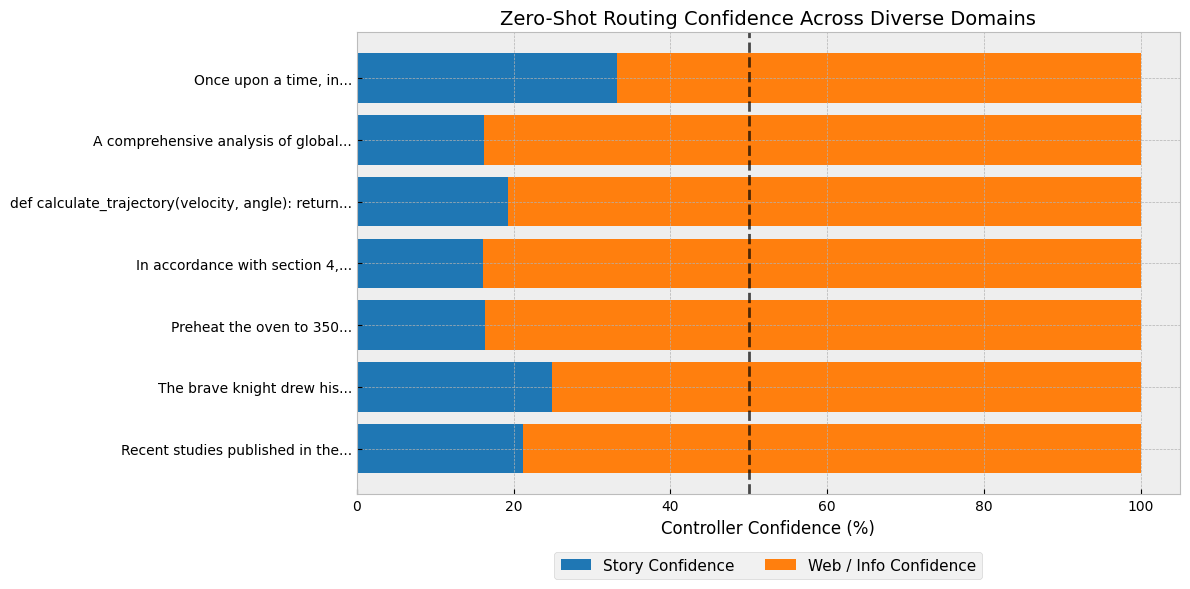

In [ ]:
# ==========================================
# 4. ZERO-SHOT STRESS TEST & CONFIDENCE PLOTTING
# ==========================================
import torch.nn.functional as F
import matplotlib.pyplot as plt

def test_continuous_recomputation(model, prompt_text):
    model.eval() # Set to inference mode

    # 1. CONTROLLER ROUTING PHASE (Must match training padding!)
    ctrl_inputs = tokenizer(
        prompt_text,
        return_tensors="pt",
        padding="max_length",
        max_length=64,
        truncation=True
    ).to(model.device)

    # 2. GENERATION PHASE (Unpadded text)
    gen_inputs = tokenizer(prompt_text, return_tensors="pt").to(model.device)

    with torch.no_grad():
        embeddings = model.base_model.get_input_embeddings()(ctrl_inputs["input_ids"])
        pooled_embeds = embeddings.mean(dim=1).to(torch.float32)
        routing_logits = model.controller(pooled_embeds)

        # Calculate Confidence Percentages
        probs = torch.softmax(routing_logits, dim=-1)[0]
        story_prob = probs[0].item() * 100
        web_prob = probs[1].item() * 100

        # Decide which LoRA to use
        domain_id = torch.argmax(routing_logits, dim=-1).item()
        domain_name = "Story" if domain_id == 0 else "Web Text"
        active_adapter = "primitive_story" if domain_id == 0 else "primitive_web"

        print(f"\n--- INFERENCE TEST ---")
        print(f"Prompt: '{prompt_text}'")
        print(f"Routing -> [{domain_name} LoRA] (Story Confidence: {story_prob:.1f}%, Web: {web_prob:.1f}%)")

        model.base_model.set_adapter(active_adapter)

        output_ids = model.base_model.generate(
            gen_inputs["input_ids"],
            attention_mask=gen_inputs.get("attention_mask", None),
            max_new_tokens=45,
            temperature=0.7,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )

        response = tokenizer.decode(output_ids[0], skip_special_tokens=True)
        print(f"Generated Output:\n{response}\n{'='*60}")

        return story_prob, web_prob

# ---------------------------------------------------------
# EXTENDED ZERO-SHOT PROMPTS (Including Out-Of-Distribution)
# ---------------------------------------------------------
extended_prompts = [
    # Baseline In-Distribution
    "Once upon a time, in a magical forest, a tiny dragon",
    "A comprehensive analysis of global macroeconomic trends indicates that",

    # Out-of-Distribution: Code
    "def calculate_trajectory(velocity, angle): \n    return",

    # Out-of-Distribution: Legal Contract
    "In accordance with section 4, paragraph B of the tenant agreement, the lessee shall",

    # Out-of-Distribution: Baking Recipe
    "Preheat the oven to 350 degrees and vigorously whisk the flour with",

    # Adversarial A: Narrative syntax with technical vocabulary
    "The brave knight drew his sword and declared that the backpropagation algorithm was failing due to",

    # Adversarial B: Academic syntax with fairy tale vocabulary
    "Recent studies published in the Journal of Medicine show that once upon a time, a beautiful princess"
]

# Track data for plotting
story_probs = []
web_probs = []
labels = []

for prompt in extended_prompts:
    s_prob, w_prob = test_continuous_recomputation(trained_model, prompt)
    story_probs.append(s_prob)
    web_probs.append(w_prob)
    # Create a short label for the graph (first 5 words)
    labels.append(" ".join(prompt.split()[:5]) + "...")

# ---------------------------------------------------------
# PLOT: ROUTING CONFIDENCE
# ---------------------------------------------------------
print("\nRendering Routing Confidence Graph...")
fig, ax = plt.subplots(figsize=(12, 6))

# Create a stacked horizontal bar chart
ax.barh(labels, story_probs, color='#1f77b4', label='Story Confidence')
ax.barh(labels, web_probs, left=story_probs, color='#ff7f0e', label='Web / Info Confidence')

ax.set_xlabel('Controller Confidence (%)', fontsize=12)
ax.set_title('Zero-Shot Routing Confidence Across Diverse Domains', fontsize=14)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=2, fontsize=11)
ax.invert_yaxis() # Read top-to-bottom

# Add a 50% line to show the decision boundary
ax.axvline(x=50, color='black', linestyle='--', linewidth=2, alpha=0.7)

plt.tight_layout()
plt.savefig('routing_confidence.png', dpi=300, bbox_inches='tight')
plt.show()

[transformers] Both `max_new_tokens` (=45) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- INFERENCE TEST ---
Prompt: 'Once upon a time, in a magical forest, a tiny dragon'
Routing -> [Story LoRA] (Story: 51.1%, Web: 48.9%)


[transformers] Both `max_new_tokens` (=45) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generated Output:
Once upon a time, in a magical forest, a tiny dragon named Mandrake lived. He was a gentle and kind creature, always ready to help his friends. One day, Mandrake heard about a terrible dragon, who was threatening the forest. The dragon was

--- INFERENCE TEST ---
Prompt: 'A comprehensive analysis of global macroeconomic trends indicates that'
Routing -> [Web Text LoRA] (Story: 2.3%, Web: 97.7%)


[transformers] Both `max_new_tokens` (=45) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Generated Output:
Suddenly, the alien spacecraft fired a massive laser beam that obliterated the planetary ecosystem around it. But the humans had been preparing for this event. They had built massive energy shields that would repel the laser's fire and shield the planet from the devastating

--- INFERENCE TEST ---
Prompt: 'The brave knight drew his sword and declared that the backpropagation algorithm was failing due to'
Routing -> [Web Text LoRA] (Story: 19.3%, Web: 80.7%)


[transformers] Both `max_new_tokens` (=45) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generated Output:
The brave knight drew his sword and declared that the backpropagation algorithm was failing due to some sort of error.

Following some online discussions, the team decided to re-evaluate the model. They decided that the best way to combat the issue was to add some randomness to the training

--- INFERENCE TEST ---
Prompt: 'Recent studies published in the Journal of Medicine show that once upon a time, a beautiful princess'
Routing -> [Web Text LoRA] (Story: 11.4%, Web: 88.6%)


[transformers] Both `max_new_tokens` (=45) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generated Output:
Recent studies published in the Journal of Medicine show that once upon a time, a beautiful princess, Lila, was a poor little girl living in a poor little town, with her poor little parents.

Once upon a time, the poor little princess Lila was born in the poor little town of H

--- INFERENCE TEST ---
Prompt: 'Materials Informatics is a '
Routing -> [Web Text LoRA] (Story: 4.0%, Web: 96.0%)
Generated Output:
Materials Informatics is a 501(c)(3) non-profit organization dedicated to developing new tools and techniques to accelerate the development and deployment of innovative materials for energy, environmental and health applications. Our mission is to promote the

Rendering Routing Confidence Graph...


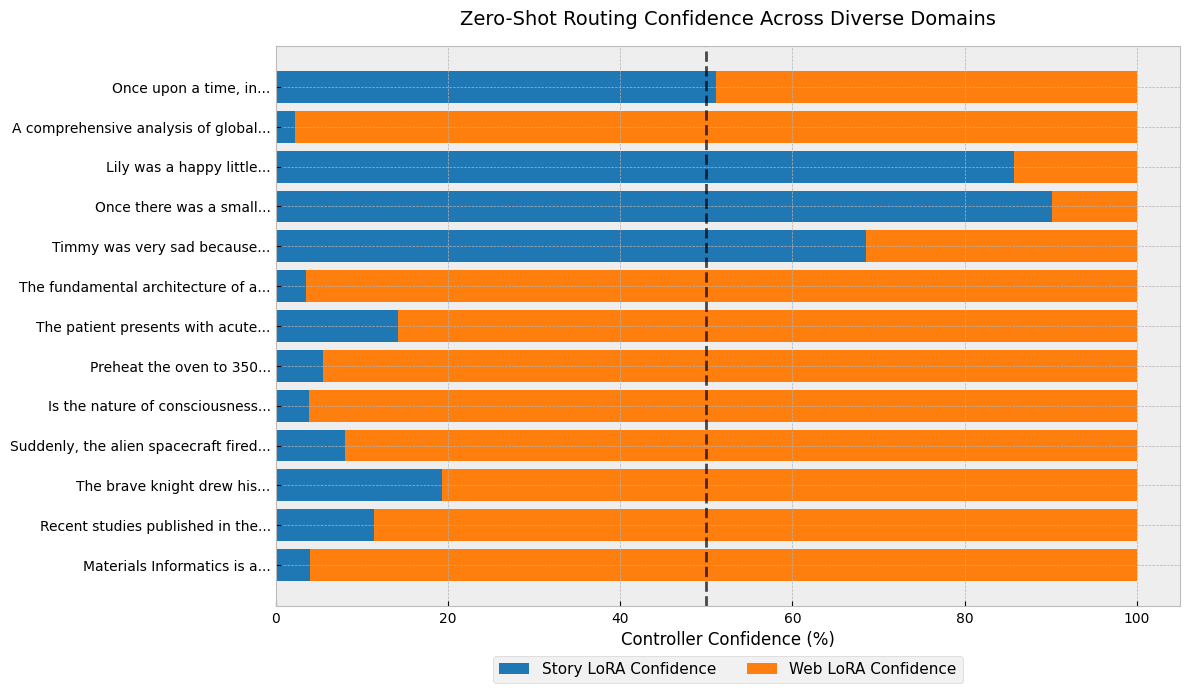

In [ ]:
# ==========================================
# 4. ZERO-SHOT STRESS TEST & CONFIDENCE PLOTTING
# ==========================================
import torch.nn.functional as F
import matplotlib.pyplot as plt

def test_continuous_recomputation(model, prompt_text):
    model.eval()

    # NO PADDING REQUIRED! Masked pooling handles raw text perfectly.
    inputs = tokenizer(prompt_text, return_tensors="pt").to(model.device)

    with torch.no_grad():
        # Masked Pooling for the Controller
        embeddings = model.base_model.get_input_embeddings()(inputs["input_ids"])
        mask_expanded = inputs["attention_mask"].unsqueeze(-1).expand(embeddings.size()).float()
        sum_embeddings = torch.sum(embeddings * mask_expanded, 1)
        sum_mask = torch.clamp(mask_expanded.sum(1), min=1e-9)
        pooled_embeds = sum_embeddings / sum_mask

        routing_logits = model.controller(pooled_embeds)

        # Calculate Confidence Percentages
        probs = torch.softmax(routing_logits, dim=-1)[0]
        story_prob = probs[0].item() * 100
        web_prob = probs[1].item() * 100

        domain_id = torch.argmax(routing_logits, dim=-1).item()
        domain_name = "Story" if domain_id == 0 else "Web Text"
        active_adapter = "primitive_story" if domain_id == 0 else "primitive_web"

        print(f"\n--- INFERENCE TEST ---")
        print(f"Prompt: '{prompt_text}'")
        print(f"Routing -> [{domain_name} LoRA] (Story: {story_prob:.1f}%, Web: {web_prob:.1f}%)")

        model.base_model.set_adapter(active_adapter)

        # Generation with attention_mask included to suppress warnings
        output_ids = model.base_model.generate(
            inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_new_tokens=45,
            temperature=0.7,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )

        response = tokenizer.decode(output_ids[0], skip_special_tokens=True)
        print(f"Generated Output:\n{response}\n{'='*60}")

        return story_prob, web_prob

# ---------------------------------------------------------
# EXTENDED ZERO-SHOT PROMPTS (Out-Of-Distribution)
# ---------------------------------------------------------
extended_prompts = [
    # 1. In-Distribution Baselines
    "Once upon a time, in a magical forest, a tiny dragon",
    "A comprehensive analysis of global macroeconomic trends indicates that",
    # True TinyStories In-Distribution Prompts
    "Lily was a happy little girl who loved to play with her toy car.",
    "Once there was a small brown dog. The dog saw a big cat and",
    "Timmy was very sad because he dropped his ice cream on the floor.",

    # OpenWebText In-Distribution Prompts
    "The fundamental architecture of a computer network consists of",
    "A comprehensive analysis of global macroeconomic trends indicates that"
    # 2. Out-of-Distribution: Code & Syntax
    "def calculate_trajectory(velocity, angle): \n    return",

    # 3. Out-of-Distribution: Medical & Clinical
    "The patient presents with acute abdominal pain, elevated heart rate, and severe nausea. We recommend",

    # 4. Out-of-Distribution: Baking Recipe
    "Preheat the oven to 350 degrees and vigorously whisk the flour with",

    # 5. Out-of-Distribution: Philosophical
    "Is the nature of consciousness an emergent property of complex neural networks, or",

    # 6. Out-of-Distribution: Sci-Fi Narrative
    "Suddenly, the alien spacecraft fired a massive laser beam that obliterated the",

    # 7. Adversarial A: Narrative syntax with technical vocabulary
    "The brave knight drew his sword and declared that the backpropagation algorithm was failing due to",

    # 8. Adversarial B: Academic syntax with fairy tale vocabulary
    "Recent studies published in the Journal of Medicine show that once upon a time, a beautiful princess",

    # 9. Out-of-Distribution: Materials Informatics
    "Materials Informatics is a "
]

story_probs, web_probs, labels = [], [], []

for prompt in extended_prompts:
    s_prob, w_prob = test_continuous_recomputation(trained_model, prompt)
    story_probs.append(s_prob)
    web_probs.append(w_prob)
    labels.append(" ".join(prompt.split()[:5]) + "...")

# ---------------------------------------------------------
# PLOT: ROUTING CONFIDENCE
# ---------------------------------------------------------
print("\nRendering Routing Confidence Graph...")
fig, ax = plt.subplots(figsize=(12, 7))

ax.barh(labels, story_probs, color='#1f77b4', label='Story LoRA Confidence')
ax.barh(labels, web_probs, left=story_probs, color='#ff7f0e', label='Web LoRA Confidence')

ax.set_xlabel('Controller Confidence (%)', fontsize=12)
ax.set_title('Zero-Shot Routing Confidence Across Diverse Domains', fontsize=14, pad=15)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=11)
ax.invert_yaxis()
ax.axvline(x=50, color='black', linestyle='--', linewidth=2, alpha=0.7)

plt.tight_layout()
plt.savefig('routing_confidence_corrected.png', dpi=300, bbox_inches='tight')
plt.show()